In [43]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import torch

# example = 'all_info_APR_3ewp_2h59_2.pkl'
# example = 'all_info_M0E_5hld_5hlb_7.pkl'
# example = 'all_info_STU_3d7t_3bkb_4.pkl'
example = 'all_info_ACO_2ou2_2cy2_4.pkl'
env = pickle.load(open(f'/home/iscb/wolfson/jeromet/LocAlign/plots/infer-virtual-bbs/val/{example}','rb'))


torch.Size([1383, 2034])


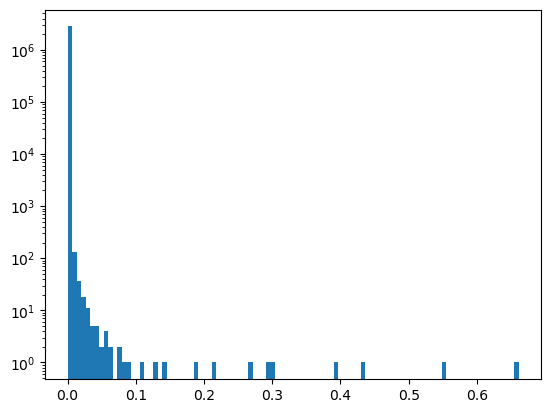

tensor(0.6610, dtype=torch.float64)
Correspondence 326,102, score=0.3928031057052478
dinit: 67.97889709472656, dgt: 1.404914379119873, dpred: 5.928102493286133
====
Correspondence 326,102, score=0.661023233658298
dinit: 66.77686309814453, dgt: 1.4569493532180786, dpred: 3.5464229583740234
====
Correspondence 328,104, score=0.4304241178935563
dinit: 59.52880859375, dgt: 1.4298899173736572, dpred: 9.53095817565918
====
Correspondence 326,102, score=0.5533171569433073
dinit: 67.26858520507812, dgt: 1.2844939231872559, dpred: 4.898438453674316
====


In [44]:
src_mask = env['batch']['src_mask'][0]
tar_mask = env['batch']['tar_mask'][0]


src_coordinates = env['batch']['src_frames'][0][src_mask][:,0]
tar_coordinates = env['batch']['tar_frames'][0][tar_mask][:,0]

src_residue_indices = env['batch']['src_residue_indices'][0][src_mask]
tar_residue_indices = env['batch']['tar_residue_indices'][0][tar_mask]

embedding_distance_matrix = env['transformation_dict']['distance_matrix'][0][tar_mask,:][:,src_mask]

gt_R,gt_t = env['batch']['gt_R'][0],env['batch']['gt_t'][0]

step = 0
pred_R,pred_t = env['transformation_dict']['all_R'][step][0],env['transformation_dict']['all_t'][step][0]

src_coordinates_moved_gt = torch.matmul(src_coordinates, gt_R) + gt_t[:3]
src_coordinates_moved_pred = torch.matmul(src_coordinates, pred_R) + pred_t[:3]

correspondence_matrix = env['transformation_dict']['all_gamma'][0][0][tar_mask,:][:,src_mask]

print(correspondence_matrix.shape)
plt.hist(correspondence_matrix.flatten(),bins=100,log=True); plt.show()

print(correspondence_matrix.max())

threshold = correspondence_matrix.max() * 0.5
location = np.nonzero(correspondence_matrix>=threshold)

for tar_index,src_index in location:
    correspondence = float(correspondence_matrix[tar_index,src_index])
    src_resindex = int(src_residue_indices[src_index])
    tar_resindex = int(tar_residue_indices[tar_index])
    
    distance_init = float(torch.sqrt(  ((src_coordinates[src_index]-tar_coordinates[tar_index])**2).sum() ))
    distance_gt = float(torch.sqrt(  ((src_coordinates_moved_gt[src_index]-tar_coordinates[tar_index])**2).sum() ))
    distance_pred = float(torch.sqrt(  ((src_coordinates_moved_pred[src_index]-tar_coordinates[tar_index])**2).sum() ))
    
    print(f'Correspondence {src_resindex},{tar_resindex}, score={correspondence}')
    print(f'dinit: {distance_init}, dgt: {distance_gt}, dpred: {distance_pred}')
    print('====')



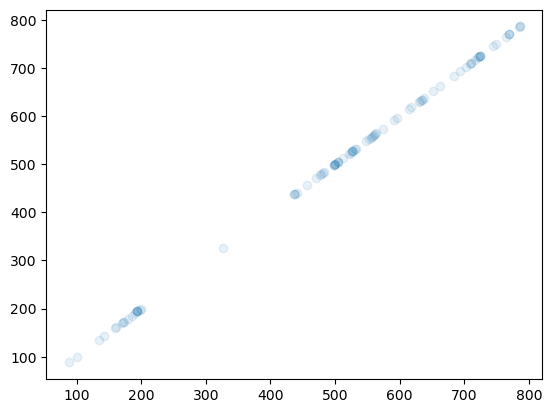

In [36]:
plt.scatter(src_residue_indices[location[:,1]],tar_residue_indices[location[:,0]],alpha=0.1)

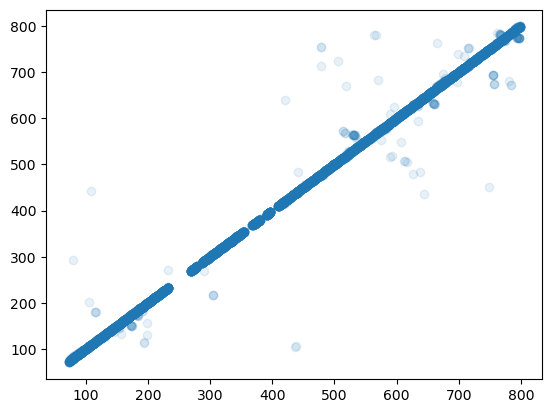

In [37]:
original_distance = np.sqrt( ( (src_coordinates_moved_gt[:,np.newaxis] - tar_coordinates[np.newaxis])**2 ).sum(-1) )
location2 = np.nonzero(original_distance <= 2)
plt.scatter(src_residue_indices[location2[:,0]],tar_residue_indices[location2[:,1]],alpha=0.1)


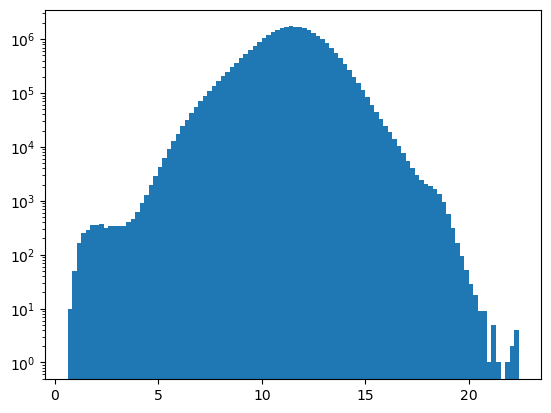

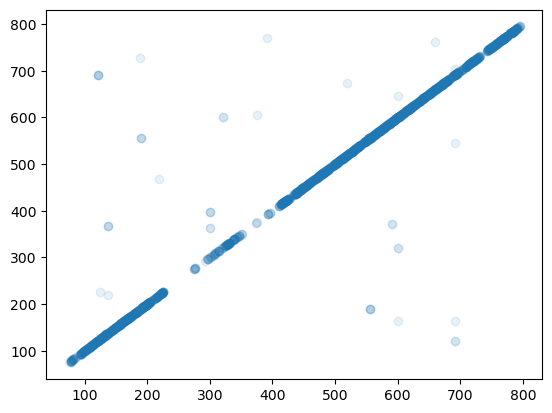

In [5]:
src_embedding = env['batch']['src_embedding'][0][src_mask]
tar_embedding = env['batch']['tar_embedding'][0][tar_mask]

embedding_distance = np.sqrt( ( (src_embedding[:,np.newaxis] - tar_embedding[np.newaxis,:])**2 ).sum(-1) )
plt.hist(embedding_distance.flatten(),bins=100,log=True); plt.show()

location3 = np.nonzero(embedding_distance <= 3)
plt.scatter(src_residue_indices[location3[:,0]],tar_residue_indices[location3[:,1]],alpha=0.1)



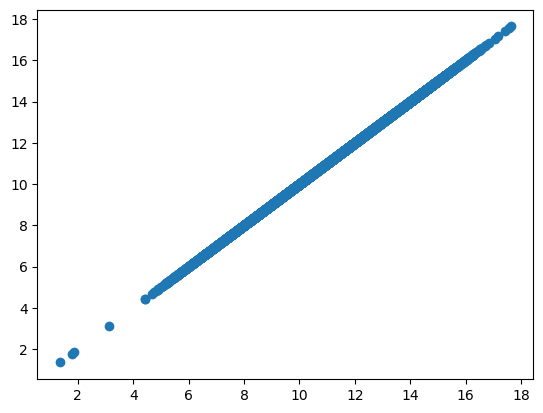

In [11]:

tmp = np.sqrt( embedding_distance_matrix * np.sqrt(256) )
# plt.hist(tmp.flatten(),bins=100,log=True); plt.show()

plt.scatter(embedding_distance[:200,:200].flatten(),tmp[:200,:200].T.flatten()); plt.show()